### Lesson 5: Human in the Loop

In [1]:
import os 
from dotenv import load_dotenv

load_dotenv()

gemini_api_key = os.getenv('GEMINI_API_KEY')
tavily_api_key = os.getenv('TAVILY_API_KEY')

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_google_genai import ChatGoogleGenerativeAI

In [4]:
# Initialize the Gemini chat model
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",  # You can choose other Gemini models like "gemini-pro"
    temperature=0.7,
    max_output_tokens=2048,
    api_key=gemini_api_key
)

E0000 00:00:1760278458.312920 13369856 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [5]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
db_path = 'checkpoints.db'
conn = sqlite3.connect(db_path, check_same_thread=False)

memory = SqliteSaver(conn)

In [6]:
from uuid import uuid4
def reduce_messages(left: list[AnyMessage], right: list[AnyMessage]) -> list[AnyMessage]:
    for message in right:
        if not message.id:
            message.id = str(uuid4())
    merged = left.copy()
    for message in right:
        for i, existing in enumerate(merged):
            if existing.id == message.id:
                merged[i] = message
                break
        else:
            merged.append(message)
    return merged

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], reduce_messages]


In [7]:
tool = TavilySearchResults(max_results=2)

/var/folders/70/3n6r904d4zb5zh68lfyslrt80000gn/T/ipykernel_18951/4289725543.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2)


In [8]:
class Agent:
    def __init__(self, model, tools, checkpointer, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile(checkpointer=checkpointer, interrupt_before=["action"])
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)
    
    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0
    
    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [9]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that! 
Use TavilySearchResults tool for getting the information for an external source.
"""

abot = Agent(llm, [tool], checkpointer=memory, system=prompt)

In [10]:
messages = [HumanMessage(content="Whats the weather forecast in SF?")]
thread = {"configurable": {"thread_id": "101"}}
for event in abot.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "current weather San Francisco"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--1f0934c3-3669-4480-b8a0-71fdf46ccb9f-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather San Francisco'}, 'id': '7047080b-9e56-43c8-994a-30bd448f3d89', 'type': 'tool_call'}], usage_metadata={'input_tokens': 766, 'output_tokens': 194, 'total_tokens': 960, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 170}})]}
()


In [11]:
abot.graph.get_state(thread).next

('action',)

In [12]:
for event in abot.graph.stream(None, thread):
    for v in event.values():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather San Francisco'}, 'id': '7047080b-9e56-43c8-994a-30bd448f3d89', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content="[{'title': 'San Francisco, CA Monthly Weather - AccuWeather', 'url': 'https://www.accuweather.com/en/us/san-francisco/94103/october-weather/347629', 'content': 'San Francisco, CA 59°F Hourly Daily Radar MinuteCast Monthly Air Quality Health & Activities October 2025', 'score': 0.46380913}, {'title': 'Weather in San Francisco in October 2025 (California)', 'url': 'https://world-weather.info/forecast/usa/san_francisco/october-2025/', 'content': 'Detailed ⚡ San Francisco Weather Forecast for October 2025 – day/night 🌡️ temperatures, precipitations – World-Weather.info.', 'score': 0.38380352}]", name='tavily_search_results_json', id='5c6d01e4-c998-4ea8-9b1a-48d6732f3989', tool_call_id='7047080b-9e56-43c8-994a-30bd448f3d89')]}
{'messages': [AIMessage(content='I am sorry, bu

#### Modify State

In [13]:
messages = [HumanMessage("Whats the weather in LA?")]
thread = {"configurable": {"thread_id": "22"}}
for event in abot.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)
while abot.graph.get_state(thread).next:
    print("\n", abot.graph.get_state(thread),"\n")
    _input = input("proceed?")
    if _input != "y":
        print("aborting")
        break
    for event in abot.graph.stream(None, thread):
        for v in event.values():
            print(v)

{'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--861bf4d3-f704-4266-b2de-af743d784f1e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '6b496d22-c5ac-4cb9-af4b-4ebc161097b8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 229, 'output_tokens': 71, 'total_tokens': 300, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 48}})]}
()

 StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='f75d0faf-1f63-4823-bd7e-f8f967953d35'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather i

In [14]:
abot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='f75d0faf-1f63-4823-bd7e-f8f967953d35'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--8c422e36-4a76-4dd6-ac80-743714d69141-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '291120b5-a002-478b-b450-318c58259c19', 'type': 'tool_call'}], usage_metadata={'input_tokens': 162, 'output_tokens': 79, 'total_tokens': 241, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 56}}), ToolMessage(content='54 degree celcius', name='tavily_search_results_json', id='24173f3d-d465-438a-aa3a-8449592efc2d', tool_call_id='291120b5-a002-478b

In [15]:
current_values = abot.graph.get_state(thread)

In [16]:
current_values.values['messages'][-1]

AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--861bf4d3-f704-4266-b2de-af743d784f1e-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '6b496d22-c5ac-4cb9-af4b-4ebc161097b8', 'type': 'tool_call'}], usage_metadata={'input_tokens': 229, 'output_tokens': 71, 'total_tokens': 300, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 48}})

In [17]:
current_values.values['messages'][-1].tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'weather in LA'},
  'id': '6b496d22-c5ac-4cb9-af4b-4ebc161097b8',
  'type': 'tool_call'}]

In [18]:
_id = current_values.values['messages'][-1].tool_calls[0]['id']
current_values.values['messages'][-1].tool_calls = [
    {'name': 'tavily_search_results_json',
  'args': {'query': 'current weather in Louisiana'},
  'id': _id}
]

In [19]:
abot.graph.update_state(thread, current_values.values)

{'configurable': {'thread_id': '22',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0a775c-9d6f-6e4c-8007-8adc581af6c5'}}

In [20]:
abot.graph.get_state(thread)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='f75d0faf-1f63-4823-bd7e-f8f967953d35'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--8c422e36-4a76-4dd6-ac80-743714d69141-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '291120b5-a002-478b-b450-318c58259c19', 'type': 'tool_call'}], usage_metadata={'input_tokens': 162, 'output_tokens': 79, 'total_tokens': 241, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 56}}), ToolMessage(content='54 degree celcius', name='tavily_search_results_json', id='24173f3d-d465-438a-aa3a-8449592efc2d', tool_call_id='291120b5-a002-478b

In [21]:
for event in abot.graph.stream(None, thread):
    for v in event.values():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Louisiana'}, 'id': '6b496d22-c5ac-4cb9-af4b-4ebc161097b8', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content='[{\'title\': \'Louisiana weather in December 2025 | Weather25.com\', \'url\': \'https://www.weather25.com/north-america/usa/louisiana?page=month&month=December\', \'content\': \'weather25.com\\nSearch\\nweather in United States\\nRemove from your favorite locations\\nAdd to my locations\\nShare\\nweather in United States\\n\\n# Louisiana weather in December 2025\\n\\nThe temperatures in Louisiana in December are usually low and can range between 12°C and 18°C.\\n\\nYou can expect about 3 to 8 days of rain in Louisiana during the month of December. It’s a good idea to bring along your umbrella so that you don’t get caught in poor weather. [...] | 14 Cloudy 19° /14° | 15 Overcast 20° /14° | 16 Moderate rain 20° /15° | 17 Patchy rain possible 16° /11° | 18 Sunny 16° /10° |

In [22]:
abot.graph.get_state(thread).values['messages'][-1]

AIMessage(content='Do you mean Los Angeles or Louisiana?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--926ff9d6-32a8-4fae-b6d0-ab53be790a57-0', usage_metadata={'input_tokens': 897, 'output_tokens': 144, 'total_tokens': 1041, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 136}})

#### Time Travel

In [23]:
states = []
for state in abot.graph.get_state_history(thread):
    print(state)
    print('--')
    states.append(state)

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='f75d0faf-1f63-4823-bd7e-f8f967953d35'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--8c422e36-4a76-4dd6-ac80-743714d69141-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '291120b5-a002-478b-b450-318c58259c19', 'type': 'tool_call'}], usage_metadata={'input_tokens': 162, 'output_tokens': 79, 'total_tokens': 241, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 56}}), ToolMessage(content='54 degree celcius', name='tavily_search_results_json', id='24173f3d-d465-438a-aa3a-8449592efc2d', tool_call_id='291120b5-a002-478b

In [24]:
to_replay = states[-3]
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='f75d0faf-1f63-4823-bd7e-f8f967953d35'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--8c422e36-4a76-4dd6-ac80-743714d69141-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '291120b5-a002-478b-b450-318c58259c19', 'type': 'tool_call'}], usage_metadata={'input_tokens': 162, 'output_tokens': 79, 'total_tokens': 241, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 56}})]}, next=('action',), config={'configurable': {'thread_id': '22', 'checkpoint_ns': '', 'checkpoint_id': '1f0a768a-aa29-6642-8001-811898e538ac'}}, metadat

In [25]:
for event in abot.graph.stream(None, to_replay.config):
    for k, v in event.items():
        print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '291120b5-a002-478b-b450-318c58259c19', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content='[{\'title\': \'Los Angeles weather in December 2025 - Weather25.com\', \'url\': \'https://www.weather25.com/north-america/usa/california/los-angeles?page=month&month=December\', \'content\': \'You can expect about 3 to 8 days of rain in Los Angeles during the month of December. It’s a good idea to bring along your umbrella so that you don’t get caught in poor weather.\\n\\nOur weather forecast can give you a great sense of what weather to expect in Los Angeles in December 2025.\\n\\nIf you’re planning to visit Los Angeles in the near future, we highly recommend that you review the 14 day weather forecast for Los Angeles before you arrive.\\n\\n19° / 11°\\n\\nRainy Days\\n\\n3\\n\\nSnowy Days\\n\\n0\\n\\nDry Days [...] | December | 19° / 11° | 3 | 28 | 0 | 66 mm | Good | Los Angeles in

#### Go Back in Time and Edit

In [26]:
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='f75d0faf-1f63-4823-bd7e-f8f967953d35'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--8c422e36-4a76-4dd6-ac80-743714d69141-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in LA'}, 'id': '291120b5-a002-478b-b450-318c58259c19', 'type': 'tool_call'}], usage_metadata={'input_tokens': 162, 'output_tokens': 79, 'total_tokens': 241, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 56}})]}, next=('action',), config={'configurable': {'thread_id': '22', 'checkpoint_ns': '', 'checkpoint_id': '1f0a768a-aa29-6642-8001-811898e538ac'}}, metadat

In [27]:
to_replay.values['messages'][-1].tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'weather in LA'},
  'id': '291120b5-a002-478b-b450-318c58259c19',
  'type': 'tool_call'}]

In [28]:
_id = to_replay.values['messages'][-1].tool_calls[0]['id']
to_replay.values['messages'][-1].tool_calls = [{'name': 'tavily_search_results_json',
  'args': {'query': 'current weather in LA, accuweather'},
  'id': _id}]

In [ ]:
branch_state = abot.graph.update_state(to_replay.config, to_replay.values)

In [30]:
for event in abot.graph.stream(None, branch_state):
    for k, v in event.items():
        if k != "__end__":
            print(v)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'current weather in LA, accuweather'}, 'id': '291120b5-a002-478b-b450-318c58259c19', 'type': 'tool_call'}
Back to the model!
{'messages': [ToolMessage(content="[{'title': 'Los Angeles, CA Monthly Weather - AccuWeather', 'url': 'https://www.accuweather.com/en/us/los-angeles/90012/december-weather/347625', 'content': '# Los Angeles, CA\\n\\nLos Angeles\\n\\nCalifornia\\n\\n## Around the Globe\\n\\nAround the Globe\\n\\n### Hurricane Tracker\\n\\n### Severe Weather\\n\\n### Radar & Maps\\n\\n### News & Features\\n\\n### Astronomy\\n\\n### Business\\n\\n### Climate\\n\\n### Health\\n\\n### Recreation\\n\\n### Sports\\n\\n### Travel\\n\\n### Warnings\\n\\n### Data Suite\\n\\n### Forensics\\n\\n### Advertising\\n\\n### Superior Accuracy™\\n\\n### Video\\n\\n### Winter Center\\n\\n## Monthly\\n\\n## December\\n\\n## 2025\\n\\n## Daily\\n\\n## Temperature Graph\\n\\n## Further Ahead\\n\\nFurther Ahead\\n\\n### January 2026 [...]

#### Add Message to a State at a Given Time

In [31]:
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Whats the weather in LA?', additional_kwargs={}, response_metadata={}, id='f75d0faf-1f63-4823-bd7e-f8f967953d35'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search_results_json', 'arguments': '{"query": "weather in LA"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--8c422e36-4a76-4dd6-ac80-743714d69141-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in LA, accuweather'}, 'id': '291120b5-a002-478b-b450-318c58259c19'}], usage_metadata={'input_tokens': 162, 'output_tokens': 79, 'total_tokens': 241, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 56}})]}, next=('action',), config={'configurable': {'thread_id': '22', 'checkpoint_ns': '', 'checkpoint_id': '1f0a768a-aa29-6642-8001-811898e538ac'}}, metadat

In [32]:
_id = to_replay.values['messages'][-1].tool_calls[0]['id']

In [33]:
state_update = {"messages": [ToolMessage(
    tool_call_id=_id,
    name="tavily_search_results_json",
    content="54 degree celcius",
)]}

In [34]:
branch_and_add = abot.graph.update_state(
    to_replay.config, 
    state_update, 
    as_node="action")

In [35]:
for event in abot.graph.stream(None, branch_and_add):
    for k, v in event.items():
        print(v)

{'messages': [AIMessage(content='The weather in LA is 54 degrees Celsius.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--b7548603-0379-44a3-bd6e-c436bdadf482-0', usage_metadata={'input_tokens': 210, 'output_tokens': 11, 'total_tokens': 221, 'input_token_details': {'cache_read': 0}})]}


## Extra Practice

### Build a Small Graph
This is a small simple graph you can tinker with if you want more insight into controlling state memory.

Define a simple 2 node graph with the following state:

- `lnode`: last node
- `scratch`: a scratchpad location
- `count` : a counter that is incremented each step

In [49]:
class AgentState(TypedDict):
    lnode: str
    scratch: str
    count: Annotated[int, operator.add]

In [50]:
def node1(state: AgentState):
    print(f"node1, count: {state['count']}")
    return {
        "lnode": "node1",
        "count": 1
    }
def node2(state: AgentState):
    print(f"node2, count: {state['count']}")
    return {
        "lnode": "node2",
        "count": 1
    }

The graph goes N1->N2->N1... but breaks after count reaches 3.

In [51]:
def should_continue(state):
    return state['count'] < 3


In [53]:
builder = StateGraph(AgentState)
builder.add_node("Node1", node1)
builder.add_node("Node2", node2)

builder.add_edge("Node1", "Node2")
builder.add_conditional_edges("Node2", should_continue, {True: "Node1", False: END})

builder.set_entry_point("Node1")


In [54]:
conn = sqlite3.connect(db_path, check_same_thread=False)

memory_2 = SqliteSaver(conn)

In [55]:
graph = builder.compile(checkpointer=memory_2)

### Run it!
Now, set the thread and run!

In [60]:
thread = {'configurable': {'thread_id': str(100)}}
graph.invoke({'count': 0, "scratch": "Hey!"}, thread)

node1, count: 0
node2, count: 1
node1, count: 2
node2, count: 3


{'lnode': 'node2', 'scratch': 'Hey!', 'count': 4}

### Look at current state

Get the current state. Note the `values` which are the AgentState. Note the `config` and the `thread_ts`. You will be using those to refer to snapshots below.

In [61]:
graph.get_state(thread)

StateSnapshot(values={'lnode': 'node2', 'scratch': 'Hey!', 'count': 4}, next=(), config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076d-6854-8004-36df413e6d53'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2025-10-12T13:25:10.261148+00:00', parent_config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076b-673e-8003-e72c5c68a01c'}}, tasks=(), interrupts=())

View all the statesnapshots in memory. You can use the displayed `count` agentstate variable to help track what you see. Notice the most recent snapshots are returned by the iterator first. Also note that there is a handy `step` variable in the metadata that counts the number of steps in the graph execution. This is a bit detailed - but you can also notice that the *parent_config* is the *config* of the previous node. At initial startup, additional states are inserted into memory to create a parent. This is something to check when you branch or *time travel* below.

#### Look at the state history

In [62]:
for state in graph.get_state_history(thread):
    print(state, "\n")

StateSnapshot(values={'lnode': 'node2', 'scratch': 'Hey!', 'count': 4}, next=(), config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076d-6854-8004-36df413e6d53'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2025-10-12T13:25:10.261148+00:00', parent_config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076b-673e-8003-e72c5c68a01c'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node1', 'scratch': 'Hey!', 'count': 3}, next=('Node2',), config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076b-673e-8003-e72c5c68a01c'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-10-12T13:25:10.260302+00:00', parent_config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076a-6046-8002-746cb0a12c14'}}, tasks=(PregelTask(id='84c903f2-474a-15ac-bd71-e02e80e74983', name='Node2', path=('__p

Store just the `config` into an list. Note the sequence of counts on the right. `get_state_history` returns the most recent snapshots first.

In [63]:
states = []
for state in graph.get_state_history(thread):
    states.append(state.config)
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076d-6854-8004-36df413e6d53'}} 4
{'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076b-673e-8003-e72c5c68a01c'}} 3
{'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-076a-6046-8002-746cb0a12c14'}} 2
{'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-0767-6292-8001-51dc7a99c7c5'}} 1
{'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-0762-6418-8000-33cfb6f80d4e'}} 0
{'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-0759-616a-bfff-6f222beedde7'}} 0


Grab an early state.

In [64]:
states[-3]

{'configurable': {'thread_id': '100',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0a76ee-0767-6292-8001-51dc7a99c7c5'}}

This is the state after Node1 completed for the first time. Note `next` is `Node2`and `count` is 1.

In [65]:
graph.get_state(states[-3])

StateSnapshot(values={'lnode': 'node1', 'scratch': 'Hey!', 'count': 1}, next=('Node2',), config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-0767-6292-8001-51dc7a99c7c5'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-10-12T13:25:10.258531+00:00', parent_config={'configurable': {'thread_id': '100', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76ee-0762-6418-8000-33cfb6f80d4e'}}, tasks=(PregelTask(id='d0eeb715-f289-1d23-d9dd-e6045c400126', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node2', 'count': 1}),), interrupts=())

#### Go Back in Time
Use that state in `invoke` to go back in time. Notice it uses states[-3] as *current_state* and continues to node2,

In [66]:
graph.invoke(None, states[-3])

node2, count: 1
node1, count: 2
node2, count: 3


{'lnode': 'node2', 'scratch': 'Hey!', 'count': 4}


Notice the new states are now in state history. Notice the counts on the far right.

In [67]:
thread = {"configurable": {"thread_id": str(1)}}
for state in graph.get_state_history(thread):
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4ea-6c86-8049-3621d0ef3f88'}} 4
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4e9-6e76-8048-7b9cd5e5bb34'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4e8-6de6-8047-a6fa97b394bf'}} 2
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4e7-6608-8046-7729e547633d'}} 1
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4e6-6050-8045-d1c690b2ee66'}} 0
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4de-6c2e-8044-94349af222aa'}} 0
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a7672-b826-6f14-8043-bd056b744f24'}} 0
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a7672-9fe0-6216-8042-c777f53a450f'}} 0
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkp

You can see the details below. Lots of text, but try to find the node that start the new branch. Notice the parent *config* is not the previous entry in the stack, but is the entry from state[-3].

In [68]:
thread = {"configurable": {"thread_id": str(1)}}
for state in graph.get_state_history(thread):
    print(state,"\n")

StateSnapshot(values={'lnode': 'node2', 'scratch': 'Hey!', 'count': 4}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4ea-6c86-8049-3621d0ef3f88'}}, metadata={'source': 'loop', 'step': 73, 'parents': {}}, created_at='2025-10-12T13:14:47.563169+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4e9-6e76-8048-7b9cd5e5bb34'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node1', 'scratch': 'Hey!', 'count': 3}, next=('Node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4e9-6e76-8048-7b9cd5e5bb34'}}, metadata={'source': 'loop', 'step': 72, 'parents': {}}, created_at='2025-10-12T13:14:47.562808+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76d6-d4e8-6de6-8047-a6fa97b394bf'}}, tasks=(PregelTask(id='19fd2c9b-8874-153b-bc1d-596fb326dda5', name='Node2', path=('__pregel_

#### Modify State
Let's start by starting a fresh thread and running to clean out history.

In [69]:
thread2 = {"configurable": {"thread_id": str(102)}}
graph.invoke({"count":0, "scratch":"hi"},thread2)

node1, count: 0
node2, count: 1
node1, count: 2
node2, count: 3


{'lnode': 'node2', 'scratch': 'hi', 'count': 4}

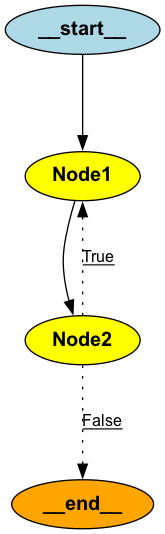

In [70]:
from IPython.display import Image

Image(graph.get_graph().draw_png())

In [71]:
states2 = []
for state in graph.get_state_history(thread2):
    states2.append(state.config)
    print(state.config, state.values['count'])   

{'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e42-6fba-8004-0141a6b56d84'}} 4
{'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e41-6fe8-8003-9b3b0574d3e2'}} 3
{'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e41-6368-8002-41de274374f6'}} 2
{'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e3e-6550-8001-926911b6965b'}} 1
{'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e3c-6aca-8000-ffa67b52e415'}} 0
{'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e38-6f88-bfff-39bec36d10b6'}} 0


Start by grabbing a state.

In [72]:
save_state = graph.get_state(states2[-3])
save_state

StateSnapshot(values={'lnode': 'node1', 'scratch': 'hi', 'count': 1}, next=('Node2',), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e3e-6550-8001-926911b6965b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-10-12T13:30:07.932544+00:00', parent_config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e3c-6aca-8000-ffa67b52e415'}}, tasks=(PregelTask(id='9ce1685d-289e-e05c-e5bb-2522ee63514a', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node2', 'count': 1}),), interrupts=())

Now modify the values. 

One subtle item to note: Recall when agent state was defined, `count` used `operator.add` to indicate that values are *added* to the current value. Here, `-3` will be added to the current count value rather than replace it.

In [73]:
save_state.values["count"] = -3
save_state.values["scratch"] = "hello"
save_state

StateSnapshot(values={'lnode': 'node1', 'scratch': 'hello', 'count': -3}, next=('Node2',), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e3e-6550-8001-926911b6965b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2025-10-12T13:30:07.932544+00:00', parent_config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e3c-6aca-8000-ffa67b52e415'}}, tasks=(PregelTask(id='9ce1685d-289e-e05c-e5bb-2522ee63514a', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node2', 'count': 1}),), interrupts=())

Now update the state. This creates a new entry at the *top*, or *latest* entry in memory. This will become the current state.

In [74]:
graph.update_state(thread2,save_state.values)

{'configurable': {'thread_id': '102',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0a76fd-c812-6866-8005-7219ac013857'}}

Current state is at the top. You can match the `thread_ts`.
Notice the `parent_config`, `thread_ts` of the new node - it is the previous node.

In [75]:
for i, state in enumerate(graph.get_state_history(thread2)):
    if i >= 3:  #print latest 3
        break
    print(state, '\n')

StateSnapshot(values={'lnode': 'node1', 'scratch': 'hello', 'count': 1}, next=('Node1',), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76fd-c812-6866-8005-7219ac013857'}}, metadata={'source': 'update', 'step': 5, 'parents': {}}, created_at='2025-10-12T13:32:13.114565+00:00', parent_config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e42-6fba-8004-0141a6b56d84'}}, tasks=(PregelTask(id='d480d78e-328e-1371-a505-ee2e772ebe5a', name='Node1', path=('__pregel_pull', 'Node1'), error=None, interrupts=(), state=None, result=None),), interrupts=()) 

StateSnapshot(values={'lnode': 'node2', 'scratch': 'hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76f9-1e42-6fba-8004-0141a6b56d84'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2025-10-12T13:30:07.934453+00:00', parent_config={'configurable': {'thread_id': '102', 'checkpoint

#### Try again with `as_node`
When writing using `update_state()`, you want to define to the graph logic which node should be assumed as the writer. What this does is allow th graph logic to find the node on the graph. After writing the values, the `next()` value is computed by travesing the graph using the new state. In this case, the state we have was written by `Node1`. The graph can then compute the next state as being `Node2`. Note that in some graphs, this may involve going through conditional edges!  Let's try this out.

In [76]:
graph.update_state(thread2,save_state.values, as_node="Node1")

{'configurable': {'thread_id': '102',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0a7701-8bab-60cc-8006-9e29a5555a3c'}}

In [77]:
for i, state in enumerate(graph.get_state_history(thread2)):
    if i >= 3:  #print latest 3
        break
    print(state, '\n')

StateSnapshot(values={'lnode': 'node1', 'scratch': 'hello', 'count': -2}, next=('Node2',), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a7701-8bab-60cc-8006-9e29a5555a3c'}}, metadata={'source': 'update', 'step': 6, 'parents': {}}, created_at='2025-10-12T13:33:54.154906+00:00', parent_config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76fd-c812-6866-8005-7219ac013857'}}, tasks=(PregelTask(id='34a7f992-a6d6-32f6-8d4d-fbb32f439daa', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result=None),), interrupts=()) 

StateSnapshot(values={'lnode': 'node1', 'scratch': 'hello', 'count': 1}, next=('Node1',), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a76fd-c812-6866-8005-7219ac013857'}}, metadata={'source': 'update', 'step': 5, 'parents': {}}, created_at='2025-10-12T13:32:13.114565+00:00', parent_config={'configurable': {'thread_id': '102

`invoke` will run from the current state if not given a particular `thread_ts`. This is now the entry that was just added.

In [78]:
graph.invoke(None,thread2)

node2, count: -2
node1, count: -1
node2, count: 0
node1, count: 1
node2, count: 2


{'lnode': 'node2', 'scratch': 'hello', 'count': 3}

Print out the state history, notice the `scratch` value change on the latest entries.

In [79]:
for state in graph.get_state_history(thread2):
    print(state,"\n")

StateSnapshot(values={'lnode': 'node2', 'scratch': 'hello', 'count': 3}, next=(), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a7702-6b9f-6066-800b-6f74ae376b89'}}, metadata={'source': 'loop', 'step': 11, 'parents': {}}, created_at='2025-10-12T13:34:17.638096+00:00', parent_config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a7702-6b99-61de-800a-c068264f00de'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node1', 'scratch': 'hello', 'count': 2}, next=('Node2',), config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a7702-6b99-61de-800a-c068264f00de'}}, metadata={'source': 'loop', 'step': 10, 'parents': {}}, created_at='2025-10-12T13:34:17.635679+00:00', parent_config={'configurable': {'thread_id': '102', 'checkpoint_ns': '', 'checkpoint_id': '1f0a7702-6b98-65fe-8009-5b2aa503c5e0'}}, tasks=(PregelTask(id='32aa986f-b5a0-1d38-eee2-15486fdf55b1', name='Node2', path=(